<a href="https://colab.research.google.com/github/OmegaS48/Internship_NITP/blob/main/Intern_Day5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [6]:
d=pd.read_csv('Train_ULAK.csv')

In [7]:
d.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,68855579,10,6,1038,11595,346,0,103.800000,167.133879,...,32,998.0,0.0,998,998,68300000.0,0.0,68300000,68300000,DoS Hulk
1,53,196,2,2,70,174,35,35,35.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,123,118,2,2,96,96,48,48,48.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,80,295657,7,10,1114,15841,1084,0,159.142857,407.829796,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,80,15705351,7,5,407,452,377,0,58.142857,140.620563,...,20,360718.0,0.0,360718,360718,9767208.0,0.0,9767208,9767208,BENIGN


In [8]:
d.drop(columns=' Destination Port',inplace=True)

In [9]:
d.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,68855579,10,6,1038,11595,346,0,103.800000,167.133879,4344,...,32,998.0,0.0,998,998,68300000.0,0.0,68300000,68300000,DoS Hulk
1,196,2,2,70,174,35,35,35.000000,0.000000,87,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,118,2,2,96,96,48,48,48.000000,0.000000,48,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,295657,7,10,1114,15841,1084,0,159.142857,407.829796,2920,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,15705351,7,5,407,452,377,0,58.142857,140.620563,220,...,20,360718.0,0.0,360718,360718,9767208.0,0.0,9767208,9767208,BENIGN


In [10]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [11]:
d.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,68855579,10,6,1038,11595,346,0,103.800000,167.133879,4344,0,1932.5,1754.831473,1.834710e+02,0.232370,4.590372e+06,1.760000e+07,68300000,2,68700000,7633007.889,2.270000e+07,68300000,2,602465,1.204930e+05,1.934046e+05,444104,49,0,0,0,0,328,200,0.145232,0.087139,0,4344,743.117647,1341.078106,1.798490e+06,0,0,0,0,1,0,0,0,0,789.562500,103.800000,1932.5,328,0,0,0,0,0,0,10,1038,6,11595,251,235,3,32,998.0,0.0,998,998,68300000.0,0.0,68300000,68300000,DoS Hulk
1,196,2,2,70,174,35,35,35.000000,0.000000,87,87,87.0,0.000000,1.244898e+06,20408.163270,6.533333e+01,1.079645e+02,190,3,3,3.000,0.000000e+00,3,3,3,3.000000e+00,0.000000e+00,3,3,0,0,0,0,64,64,10204.081630,10204.081630,35,87,55.800000,28.481573,8.112000e+02,0,0,0,0,0,0,0,0,1,69.750000,35.000000,87.0,64,0,0,0,0,0,0,2,70,2,174,-1,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,118,2,2,96,96,48,48,48.000000,0.000000,48,48,48.0,0.000000,1.627119e+06,33898.305080,3.933333e+01,6.206717e+01,111,3,3,3.000,0.000000e+00,3,3,4,4.000000e+00,0.000000e+00,4,4,0,0,0,0,40,40,16949.152540,16949.152540,48,48,48.000000,0.000000,0.000000e+00,0,0,0,0,0,0,0,0,1,60.000000,48.000000,48.0,40,0,0,0,0,0,0,2,96,2,96,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,295657,7,10,1114,15841,1084,0,159.142857,407.829796,2920,0,1584.1,792.273304,5.734686e+04,57.499061,1.847856e+04,5.298594e+04,209299,1,295464,49244.000,8.134591e+04,209299,192,262576,2.917511e+04,8.701429e+04,261213,2,0,0,0,0,152,208,23.676084,33.822977,0,2920,941.944444,968.551646,9.380923e+05,0,0,0,1,0,0,0,0,1,997.352941,159.142857,1584.1,152,0,0,0,0,0,0,7,1114,10,15841,8192,11,6,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,15705351,7,5,407,452,377,0,58.142857,140.620563,220,0,90.4,118.333427,5.469473e+01,0.764071,1.427759e+06,3.221493e+06,9767208,82,15700000,2617558.500,4.134537e+06,9767208,375,10100000,2.532037e+06,4.846203e+06,9799947,1261,0,0,0,0,152,108,0.445708,0.318363,0,377,66.076923,123.295351,1.520174e+04,0,0,0,1,0,0,0,0,0,71.583333,58.142857,90.4,152,0,0,0,0,0,0,7,407,5,452,8192,16384,6,20,360718.0,0.0,360718,360718,9767208.0,0.0,9767208,9767208,BENIGN


In [12]:
d.dtypes

,0
Flow Duration,int64
Total Fwd Packets,int64
Total Backward Packets,int64
Total Length of Fwd Packets,int64
Total Length of Bwd Packets,int64
Fwd Packet Length Max,int64
Fwd Packet Length Min,int64
Fwd Packet Length Mean,float64
Fwd Packet Length Std,float64
Bwd Packet Length Max,int64


In [13]:
labelencoder=LabelEncoder()

In [14]:
target=labelencoder.fit_transform(d[' Label'])

In [15]:
d[' Label']=target

In [16]:
d.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,68855579,10,6,1038,11595,346,0,103.800000,167.133879,4344,0,1932.5,1754.831473,1.834710e+02,0.232370,4.590372e+06,1.760000e+07,68300000,2,68700000,7633007.889,2.270000e+07,68300000,2,602465,1.204930e+05,1.934046e+05,444104,49,0,0,0,0,328,200,0.145232,0.087139,0,4344,743.117647,1341.078106,1.798490e+06,0,0,0,0,1,0,0,0,0,789.562500,103.800000,1932.5,328,0,0,0,0,0,0,10,1038,6,11595,251,235,3,32,998.0,0.0,998,998,68300000.0,0.0,68300000,68300000,4
1,196,2,2,70,174,35,35,35.000000,0.000000,87,87,87.0,0.000000,1.244898e+06,20408.163270,6.533333e+01,1.079645e+02,190,3,3,3.000,0.000000e+00,3,3,3,3.000000e+00,0.000000e+00,3,3,0,0,0,0,64,64,10204.081630,10204.081630,35,87,55.800000,28.481573,8.112000e+02,0,0,0,0,0,0,0,0,1,69.750000,35.000000,87.0,64,0,0,0,0,0,0,2,70,2,174,-1,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2,118,2,2,96,96,48,48,48.000000,0.000000,48,48,48.0,0.000000,1.627119e+06,33898.305080,3.933333e+01,6.206717e+01,111,3,3,3.000,0.000000e+00,3,3,4,4.000000e+00,0.000000e+00,4,4,0,0,0,0,40,40,16949.152540,16949.152540,48,48,48.000000,0.000000,0.000000e+00,0,0,0,0,0,0,0,0,1,60.000000,48.000000,48.0,40,0,0,0,0,0,0,2,96,2,96,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,295657,7,10,1114,15841,1084,0,159.142857,407.829796,2920,0,1584.1,792.273304,5.734686e+04,57.499061,1.847856e+04,5.298594e+04,209299,1,295464,49244.000,8.134591e+04,209299,192,262576,2.917511e+04,8.701429e+04,261213,2,0,0,0,0,152,208,23.676084,33.822977,0,2920,941.944444,968.551646,9.380923e+05,0,0,0,1,0,0,0,0,1,997.352941,159.142857,1584.1,152,0,0,0,0,0,0,7,1114,10,15841,8192,11,6,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,15705351,7,5,407,452,377,0,58.142857,140.620563,220,0,90.4,118.333427,5.469473e+01,0.764071,1.427759e+06,3.221493e+06,9767208,82,15700000,2617558.500,4.134537e+06,9767208,375,10100000,2.532037e+06,4.846203e+06,9799947,1261,0,0,0,0,152,108,0.445708,0.318363,0,377,66.076923,123.295351,1.520174e+04,0,0,0,1,0,0,0,0,0,71.583333,58.142857,90.4,152,0,0,0,0,0,0,7,407,5,452,8192,16384,6,20,360718.0,0.0,360718,360718,9767208.0,0.0,9767208,9767208,0


In [17]:
scaler=StandardScaler()

In [18]:
np.isinf(d).sum()

,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0


In [19]:
d=d.replace([np.inf,-np.inf],0)

In [20]:
np.isinf(d).sum()

,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0


In [21]:
Y=target

In [22]:
X=d

In [23]:
X.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,68855579,10,6,1038,11595,346,0,103.800000,167.133879,4344,0,1932.5,1754.831473,1.834710e+02,0.232370,4.590372e+06,1.760000e+07,68300000,2,68700000,7633007.889,2.270000e+07,68300000,2,602465,1.204930e+05,1.934046e+05,444104,49,0,0,0,0,328,200,0.145232,0.087139,0,4344,743.117647,1341.078106,1.798490e+06,0,0,0,0,1,0,0,0,0,789.562500,103.800000,1932.5,328,0,0,0,0,0,0,10,1038,6,11595,251,235,3,32,998.0,0.0,998,998,68300000.0,0.0,68300000,68300000,4
1,196,2,2,70,174,35,35,35.000000,0.000000,87,87,87.0,0.000000,1.244898e+06,20408.163270,6.533333e+01,1.079645e+02,190,3,3,3.000,0.000000e+00,3,3,3,3.000000e+00,0.000000e+00,3,3,0,0,0,0,64,64,10204.081630,10204.081630,35,87,55.800000,28.481573,8.112000e+02,0,0,0,0,0,0,0,0,1,69.750000,35.000000,87.0,64,0,0,0,0,0,0,2,70,2,174,-1,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2,118,2,2,96,96,48,48,48.000000,0.000000,48,48,48.0,0.000000,1.627119e+06,33898.305080,3.933333e+01,6.206717e+01,111,3,3,3.000,0.000000e+00,3,3,4,4.000000e+00,0.000000e+00,4,4,0,0,0,0,40,40,16949.152540,16949.152540,48,48,48.000000,0.000000,0.000000e+00,0,0,0,0,0,0,0,0,1,60.000000,48.000000,48.0,40,0,0,0,0,0,0,2,96,2,96,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,295657,7,10,1114,15841,1084,0,159.142857,407.829796,2920,0,1584.1,792.273304,5.734686e+04,57.499061,1.847856e+04,5.298594e+04,209299,1,295464,49244.000,8.134591e+04,209299,192,262576,2.917511e+04,8.701429e+04,261213,2,0,0,0,0,152,208,23.676084,33.822977,0,2920,941.944444,968.551646,9.380923e+05,0,0,0,1,0,0,0,0,1,997.352941,159.142857,1584.1,152,0,0,0,0,0,0,7,1114,10,15841,8192,11,6,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,15705351,7,5,407,452,377,0,58.142857,140.620563,220,0,90.4,118.333427,5.469473e+01,0.764071,1.427759e+06,3.221493e+06,9767208,82,15700000,2617558.500,4.134537e+06,9767208,375,10100000,2.532037e+06,4.846203e+06,9799947,1261,0,0,0,0,152,108,0.445708,0.318363,0,377,66.076923,123.295351,1.520174e+04,0,0,0,1,0,0,0,0,0,71.583333,58.142857,90.4,152,0,0,0,0,0,0,7,407,5,452,8192,16384,6,20,360718.0,0.0,360718,360718,9767208.0,0.0,9767208,9767208,0


In [24]:
Y

array([4, 0, 0, ..., 3, 0, 0])

In [25]:
scaler

StandardScaler()

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [28]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [29]:
X_train

array([[ 3.11500494e+00,  8.94273563e-02,  1.16321933e-01, ...,
         2.04511444e+00,  2.09154939e+00, -4.12800179e-01],
       [-4.39119828e-01, -1.18440519e-02, -1.00080020e-02, ...,
        -3.56606584e-01, -3.38386579e-01,  3.46375781e+00],
       [-4.39120125e-01, -1.04176940e-02, -8.93740934e-03, ...,
        -3.56606584e-01, -3.38386579e-01, -4.12800179e-01],
       ...,
       [-4.39120601e-01, -1.18440519e-02, -1.00080020e-02, ...,
        -3.56606584e-01, -3.38386579e-01,  3.46375781e+00],
       [-2.62736334e-01,  5.27224245e-03,  1.76851734e-03, ...,
        -1.30642899e-01, -1.02510594e-01, -4.12800179e-01],
       [-4.39117065e-01, -1.04176940e-02, -8.93740934e-03, ...,
        -3.56606584e-01, -3.38386579e-01, -4.12800179e-01]])

In [30]:
from xgboost import XGBClassifier

In [31]:
xgb=XGBClassifier()

In [32]:
estimators=[('xgb',xgb)]

In [33]:
from sklearn.pipeline import Pipeline

In [34]:
pipe=Pipeline(steps=estimators)

In [35]:
!pip install scikit_optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.5 MB/s eta 0:00:00


In [36]:
from skopt import BayesSearchCV

In [37]:
from skopt.space import Real,Categorical,Integer

In [38]:
search_space = {
    'max_depth': Integer(3, 8),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'n_estimators': Integer(100, 500),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'reg_alpha': Real(0.0, 5.0),
    'reg_lambda': Real(0.1, 5.0),
    'gamma': Real(0.0, 5.0)
}

In [39]:
opt=BayesSearchCV(pipe,search_space,n_iter=100,cv=2,scoring='roc_auc',random_state=8)

In [40]:
opt = BayesSearchCV(
    xgb,
    search_spaces=search_space,
    n_iter=10,
    cv=2
)

In [41]:
q=pd.DataFrame(Y)

In [42]:
q.value_counts()

,count
0,
0,581639
4,58790
10,40800
2,32679
3,2635
7,1988
11,1558
6,1481
5,1398


In [43]:
q=q[q!=8]

In [44]:
q.value_counts()

,count
0,
0.0,581639
4.0,58790
10.0,40800
2.0,32679
3.0,2635
7.0,1988
11.0,1558
6.0,1481
5.0,1398


In [45]:
Y=q

In [46]:
X_train.shape

(579224, 78)

In [47]:
X_test.shape

(144807, 78)

In [48]:
Y_train.fillna(0,inplace=True)

AttributeError: 'numpy.ndarray' object has no attribute 'fillna'

In [49]:
Y_train.shape

(579224,)

In [50]:
Y_train.dtypes

AttributeError: 'numpy.ndarray' object has no attribute 'dtypes'

In [ ]:
Y_train.value_counts()

In [51]:
from sklearn.preprocessing import LabelEncoder

In [52]:
labelencoder=LabelEncoder()

In [53]:
d.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,68855579,10,6,1038,11595,346,0,103.800000,167.133879,4344,0,1932.5,1754.831473,1.834710e+02,0.232370,4.590372e+06,1.760000e+07,68300000,2,68700000,7633007.889,2.270000e+07,68300000,2,602465,1.204930e+05,1.934046e+05,444104,49,0,0,0,0,328,200,0.145232,0.087139,0,4344,743.117647,1341.078106,1.798490e+06,0,0,0,0,1,0,0,0,0,789.562500,103.800000,1932.5,328,0,0,0,0,0,0,10,1038,6,11595,251,235,3,32,998.0,0.0,998,998,68300000.0,0.0,68300000,68300000,4
1,196,2,2,70,174,35,35,35.000000,0.000000,87,87,87.0,0.000000,1.244898e+06,20408.163270,6.533333e+01,1.079645e+02,190,3,3,3.000,0.000000e+00,3,3,3,3.000000e+00,0.000000e+00,3,3,0,0,0,0,64,64,10204.081630,10204.081630,35,87,55.800000,28.481573,8.112000e+02,0,0,0,0,0,0,0,0,1,69.750000,35.000000,87.0,64,0,0,0,0,0,0,2,70,2,174,-1,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2,118,2,2,96,96,48,48,48.000000,0.000000,48,48,48.0,0.000000,1.627119e+06,33898.305080,3.933333e+01,6.206717e+01,111,3,3,3.000,0.000000e+00,3,3,4,4.000000e+00,0.000000e+00,4,4,0,0,0,0,40,40,16949.152540,16949.152540,48,48,48.000000,0.000000,0.000000e+00,0,0,0,0,0,0,0,0,1,60.000000,48.000000,48.0,40,0,0,0,0,0,0,2,96,2,96,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,295657,7,10,1114,15841,1084,0,159.142857,407.829796,2920,0,1584.1,792.273304,5.734686e+04,57.499061,1.847856e+04,5.298594e+04,209299,1,295464,49244.000,8.134591e+04,209299,192,262576,2.917511e+04,8.701429e+04,261213,2,0,0,0,0,152,208,23.676084,33.822977,0,2920,941.944444,968.551646,9.380923e+05,0,0,0,1,0,0,0,0,1,997.352941,159.142857,1584.1,152,0,0,0,0,0,0,7,1114,10,15841,8192,11,6,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,15705351,7,5,407,452,377,0,58.142857,140.620563,220,0,90.4,118.333427,5.469473e+01,0.764071,1.427759e+06,3.221493e+06,9767208,82,15700000,2617558.500,4.134537e+06,9767208,375,10100000,2.532037e+06,4.846203e+06,9799947,1261,0,0,0,0,152,108,0.445708,0.318363,0,377,66.076923,123.295351,1.520174e+04,0,0,0,1,0,0,0,0,0,71.583333,58.142857,90.4,152,0,0,0,0,0,0,7,407,5,452,8192,16384,6,20,360718.0,0.0,360718,360718,9767208.0,0.0,9767208,9767208,0


In [54]:
X=d
Y=target

In [55]:
df=pd.DataFrame(Y)

In [56]:
df.value_counts()

,count
0,
0,581639
4,58790
10,40800
2,32679
3,2635
7,1988
11,1558
6,1481
5,1398


In [57]:
df.isnull().sum()

,0
0,0


In [58]:
df.shape

(724031, 1)

In [59]:
X.shape

(724031, 78)

In [60]:
X=d

In [61]:
Y=df

In [62]:
X.isnull().sum()

,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0


In [63]:
X.fillna(0,inplace=True)

In [64]:
X.isnull().sum()

,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0


In [65]:
Y.isnull().sum()

,0
0,0


In [66]:
Y.value_counts()

,count
0,
0,581639
4,58790
10,40800
2,32679
3,2635
7,1988
11,1558
6,1481
5,1398


In [67]:
Y=Y[Y!=8]

In [68]:
Y.value_counts()

,count
0,
0.0,581639
4.0,58790
10.0,40800
2.0,32679
3.0,2635
7.0,1988
11.0,1558
6.0,1481
5.0,1398


In [69]:
Y=labelencoder.fit_transform(Y)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [70]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [71]:
X_train.shape

(579224, 78)

In [72]:
Y_train.shape

(579224,)

In [73]:
from xgboost import XGBClassifier

In [74]:
xgb=XGBClassifier()

In [75]:
estimators=[('xgb',xgb)]

In [76]:
from sklearn.pipeline import Pipeline

In [77]:
pipe=Pipeline(steps=estimators)

In [78]:
!pip install scikit_optimize

In [79]:
from skopt import BayesSearchCV

In [80]:
from skopt.space import Real,Categorical,Integer

In [81]:
search_space = {
    'max_depth': Integer(3, 8),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'n_estimators': Integer(100, 500),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'reg_alpha': Real(0.0, 5.0),
    'reg_lambda': Real(0.1, 5.0),
    'gamma': Real(0.0, 5.0)
}

In [82]:
opt=BayesSearchCV(pipe,search_space,n_iter=10,cv=2,scoring='roc_auc',random_state=8)

In [83]:
opt = BayesSearchCV(
    xgb,
    search_spaces=search_space,
    n_iter=10,
    cv=2)

In [85]:
e=pd.DataFrame(Y_train)

In [86]:
e.value_counts()

,count
0,
0,465262
4,47065
9,32607
2,26196
3,2118
7,1575
10,1247
6,1193
5,1116


In [87]:
e=e[e!=14]

In [89]:
e=e[e!=8]

In [90]:
e=e[e!=12]

In [91]:
e.value_counts()

,count
0,
0.0,465262
4.0,47065
9.0,32607
2.0,26196
3.0,2118
7.0,1575
10.0,1247
6.0,1193
5.0,1116


In [92]:
e.isnull().sum()

,0
0,9


In [93]:
e.fillna(0,inplace=True)

In [94]:
e.isnull().sum()

,0
0,0


In [95]:
e.value_counts()

,count
0,
0.0,465271
4.0,47065
9.0,32607
2.0,26196
3.0,2118
7.0,1575
10.0,1247
6.0,1193
5.0,1116


In [96]:
f=e.to_numpy()

In [97]:
Y_train=f

In [103]:
Y_train.shape

(579224,)

In [104]:
X_train.shape

(579224, 78)

In [102]:
Y_train=labelencoder.fit_transform(Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [105]:
opt.fit(X_train,Y_train)

BayesSearchCV(cv=2,
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric=None, feature_types=None,
                                      feature_weights=None, gamma=None,
                                      grow_policy=None, importance_type=None,
                                      interaction_constraints=No...
                             'max_depth': Integer(low=3, high=8, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=100, high=500, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=0.0, high=5.0, prior='uniform', transform='normalize'),
                             'reg_lambda': Real(low=0.1, high=5.0, prior='uniform', transform='normalize'),
                             'subsample': Real(low=0.6, high=1.0, prior='uniform', transform='normalize')})

In [106]:
opt.best_params_

OrderedDict([('colsample_bytree', 0.8270130889834539),
             ('gamma', 0.6372936374566769),
             ('learning_rate', 0.022062317376289567),
             ('max_depth', 6),
             ('n_estimators', 445),
             ('reg_alpha', 2.587231136259942),
             ('reg_lambda', 0.5113611141161409),
             ('subsample', 0.9477575917058887)])

In [107]:
opt.best_score_

np.float64(0.9999930942088036)

In [108]:
opt.predict_proba(X_test)

array([[9.9996257e-01, 1.1325710e-06, 8.6032433e-06, ..., 1.4237033e-06,
        6.9987874e-07, 4.5742991e-07],
       [9.9996126e-01, 1.2548578e-06, 8.1690723e-06, ..., 1.8702358e-06,
        1.0058201e-06, 5.3279757e-07],
       [9.9996984e-01, 7.8426490e-07, 7.0932242e-06, ..., 1.2319395e-06,
        6.0560888e-07, 3.9581658e-07],
       ...,
       [9.9996984e-01, 7.8426490e-07, 7.4402810e-06, ..., 1.2319395e-06,
        6.0560888e-07, 3.9581658e-07],
       [9.9997067e-01, 7.8426552e-07, 6.5949548e-06, ..., 1.2329078e-06,
        6.0560939e-07, 3.9581693e-07],
       [9.9996233e-01, 1.3606191e-06, 8.5729534e-06, ..., 1.8078764e-06,
        7.5248875e-07, 4.9053250e-07]], dtype=float32)

In [109]:
Y_pred=opt.predict(X_test)

In [110]:
from sklearn.metrics import accuracy_score

In [111]:
accuracy_score(Y_test,Y_pred)

0.9405070196882748

In [112]:
test=pd.read_csv('Test_ULAK.csv')

In [113]:
test.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,998,2,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,2004.008016,9.980000e+02,0.000000e+00,998,998,998,998.0,0.0,998,998,0,0.0,0.0,0,0,0,0,0,0,64,0,2004.008016,0.000000,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,0,0.00,0.0,0.0,64,0,0,0,0,0,0,2,0,0,0,251,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
1,80,63111103,7,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,0.110916,1.050000e+07,1.190000e+07,32100000,999612,63100000,10500000.0,11900000.0,32100000,999612,0,0.0,0.0,0,0,0,0,0,0,280,0,0.110916,0.000000,0,0,0.0,0.000000,0.0,0,0,0,1,0,0,0,0,0,0.00,0.0,0.0,280,0,0,0,0,0,0,7,0,0,0,29200,-1,0,40,7015565.0,0.0,7015565,7015565,18700000.0,12200000.0,32100000,8015910,DoS Slowhttptest
2,53,202,2,2,98,130,49,49,49.0,0.0,65,65,65.0,0.0,1.128713e+06,19801.980200,6.733333e+01,3.348632e+01,106,48,48,48.0,0.0,48,48,48,48.0,0.0,48,48,0,0,0,0,40,40,9900.990099,9900.990099,49,65,55.4,8.763561,76.8,0,0,0,0,0,0,0,0,1,69.25,49.0,65.0,40,0,0,0,0,0,0,2,98,2,130,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,80,3,2,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,666666.666700,3.000000e+00,0.000000e+00,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,64,0,666666.666700,0.000000,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,0,0.00,0.0,0.0,64,0,0,0,0,0,0,2,0,0,0,274,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
4,7200,37,1,1,0,6,0,0,0.0,0.0,6,6,6.0,0.0,1.621622e+05,54054.054050,3.700000e+01,0.000000e+00,37,37,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,40,20,27027.027030,27027.027030,0,6,2.0,3.464102,12.0,0,0,0,1,0,0,0,0,1,3.00,0.0,6.0,40,0,0,0,0,0,0,1,0,1,6,29200,0,0,40,0.0,0.0,0,0,0.0,0.0,0,0,PortScan


[[116377      0      0      0      0      0      0      0      0      0
       0      0      0      0]
 [     0    107      0      0      0      0      0      0      0      0
       0      0      0      0]
 [     0      0   6483      0      0      0      0      0      0      0
       0      0      0      0]
 [     0      0      0    517      0      0      0      0      0      0
       0      0      0      0]
 [     0      0      0      0  11725      0      0      0      0      0
       0      0      0      0]
 [     0      0      0      0      0    282      0      0      0      0
       0      0      0      0]
 [     0      0      0      0      0      0    288      0      0      0
       0      0      0      0]
 [     0      0      0      0      0      0      0    413      0      0
       0      0      0      0]
 [     3      0      0      0      0      0      0      0      0      0
       0      0      0      0]
 [     0      0      0      0      0      0      0      0   8193      0
 

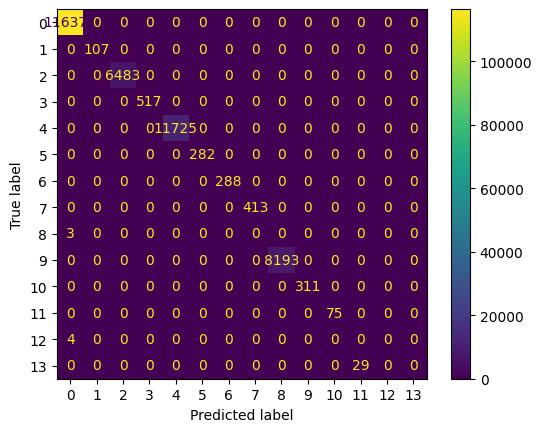

In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
Y_pred = opt.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

print(cm)

# Display it nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [118]:
from sklearn.metrics import classification_report

# Predict on test data
Y_pred = opt.predict(X_test)

# Generate report
report = classification_report(Y_test,Y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    116377
           1       1.00      1.00      1.00       107
           2       1.00      1.00      1.00      6483
           3       1.00      1.00      1.00       517
           4       1.00      1.00      1.00     11725
           5       1.00      1.00      1.00       282
           6       1.00      1.00      1.00       288
           7       1.00      1.00      1.00       413
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00      8193
          10       0.00      0.00      0.00       311
          11       0.00      0.00      0.00        75
          12       0.00      0.00      0.00         4
          13       0.00      0.00      0.00        29

    accuracy                           0.94    144807
   macro avg       0.57      0.57      0.57    144807
weighted avg       0.94      0.94      0.94    144807



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [119]:
test.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,998,2,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,2004.008016,9.980000e+02,0.000000e+00,998,998,998,998.0,0.0,998,998,0,0.0,0.0,0,0,0,0,0,0,64,0,2004.008016,0.000000,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,0,0.00,0.0,0.0,64,0,0,0,0,0,0,2,0,0,0,251,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,4
1,63111103,7,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,0.110916,1.050000e+07,1.190000e+07,32100000,999612,63100000,10500000.0,11900000.0,32100000,999612,0,0.0,0.0,0,0,0,0,0,0,280,0,0.110916,0.000000,0,0,0.0,0.000000,0.0,0,0,0,1,0,0,0,0,0,0.00,0.0,0.0,280,0,0,0,0,0,0,7,0,0,0,29200,-1,0,40,7015565.0,0.0,7015565,7015565,18700000.0,12200000.0,32100000,8015910,5
2,202,2,2,98,130,49,49,49.0,0.0,65,65,65.0,0.0,1.128713e+06,19801.980200,6.733333e+01,3.348632e+01,106,48,48,48.0,0.0,48,48,48,48.0,0.0,48,48,0,0,0,0,40,40,9900.990099,9900.990099,49,65,55.4,8.763561,76.8,0,0,0,0,0,0,0,0,1,69.25,49.0,65.0,40,0,0,0,0,0,0,2,98,2,130,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,3,2,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,666666.666700,3.000000e+00,0.000000e+00,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,64,0,666666.666700,0.000000,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,0,0.00,0.0,0.0,64,0,0,0,0,0,0,2,0,0,0,274,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,4
4,37,1,1,0,6,0,0,0.0,0.0,6,6,6.0,0.0,1.621622e+05,54054.054050,3.700000e+01,0.000000e+00,37,37,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,40,20,27027.027030,27027.027030,0,6,2.0,3.464102,12.0,0,0,0,1,0,0,0,0,1,3.00,0.0,6.0,40,0,0,0,0,0,0,1,0,1,6,29200,0,0,40,0.0,0.0,0,0,0.0,0.0,0,0,10


In [114]:
test.drop(columns=' Destination Port',inplace=True)

In [115]:
target=labelencoder.fit_transform(test[' Label'])

In [116]:
test[' Label']=target

In [120]:
test.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,998,2,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,2004.008016,9.980000e+02,0.000000e+00,998,998,998,998.0,0.0,998,998,0,0.0,0.0,0,0,0,0,0,0,64,0,2004.008016,0.000000,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,0,0.00,0.0,0.0,64,0,0,0,0,0,0,2,0,0,0,251,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,4
1,63111103,7,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,0.110916,1.050000e+07,1.190000e+07,32100000,999612,63100000,10500000.0,11900000.0,32100000,999612,0,0.0,0.0,0,0,0,0,0,0,280,0,0.110916,0.000000,0,0,0.0,0.000000,0.0,0,0,0,1,0,0,0,0,0,0.00,0.0,0.0,280,0,0,0,0,0,0,7,0,0,0,29200,-1,0,40,7015565.0,0.0,7015565,7015565,18700000.0,12200000.0,32100000,8015910,5
2,202,2,2,98,130,49,49,49.0,0.0,65,65,65.0,0.0,1.128713e+06,19801.980200,6.733333e+01,3.348632e+01,106,48,48,48.0,0.0,48,48,48,48.0,0.0,48,48,0,0,0,0,40,40,9900.990099,9900.990099,49,65,55.4,8.763561,76.8,0,0,0,0,0,0,0,0,1,69.25,49.0,65.0,40,0,0,0,0,0,0,2,98,2,130,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,3,2,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,666666.666700,3.000000e+00,0.000000e+00,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,64,0,666666.666700,0.000000,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,0,0.00,0.0,0.0,64,0,0,0,0,0,0,2,0,0,0,274,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,4
4,37,1,1,0,6,0,0,0.0,0.0,6,6,6.0,0.0,1.621622e+05,54054.054050,3.700000e+01,0.000000e+00,37,37,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,40,20,27027.027030,27027.027030,0,6,2.0,3.464102,12.0,0,0,0,1,0,0,0,0,1,3.00,0.0,6.0,40,0,0,0,0,0,0,1,0,1,6,29200,0,0,40,0.0,0.0,0,0,0.0,0.0,0,0,10


In [121]:
target

array([4, 5, 0, ..., 4, 4, 0])

In [208]:
Xt=test
Yt=target

In [209]:
np.isinf(Xt).sum()

,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0


In [210]:
np.isinf(Yt).sum()

np.int64(0)

In [211]:
Xt.replace([np.inf,-np.inf],0,inplace=True)

In [212]:
np.isinf(Xt).sum()

,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0


In [213]:
Xt.isnull().sum()

,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0


In [214]:
Xt.fillna(0,inplace=True)

In [215]:
Xt.isnull().sum()

,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0


In [130]:
opt.fit(Xt,Yt)

BayesSearchCV(cv=2,
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric=None, feature_types=None,
                                      feature_weights=None, gamma=None,
                                      grow_policy=None, importance_type=None,
                                      interaction_constraints=No...
                             'max_depth': Integer(low=3, high=8, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=100, high=500, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=0.0, high=5.0, prior='uniform', transform='normalize'),
                             'reg_lambda': Real(low=0.1, high=5.0, prior='uniform', transform='normalize'),
                             'subsample': Real(low=0.6, high=1.0, prior='uniform', transform='normalize')})

In [179]:
from sklearn.metrics import classification_report

# Predict on test data
Ypt= opt.predict(Xt)

# Generate report
report_new = classification_report(Yt,Ypt)

print(report_new)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    411203
           1       1.00      1.00      1.00       355
           2       1.00      1.00      1.00     23160
           3       1.00      1.00      1.00      1861
           4       1.00      1.00      1.00     41801
           5       1.00      1.00      1.00       994
           6       1.00      1.00      1.00      1048
           7       1.00      1.00      1.00      1436
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         6
          10       1.00      1.00      1.00     28751
          11       1.00      1.00      1.00      1067
          12       1.00      1.00      1.00       272
          13       0.00      0.00      0.00         4
          14       1.00      1.00      1.00       117

    accuracy                           1.00    512077
   macro avg       0.80      0.80      0.80    512077
weighted avg       1.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [198]:
from sklearn.metrics import classification_report

# Predict on test data
Y_pred = opt.predict(X_test)

# Generate report
report = classification_report(Y_test,Y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    116377
           1       1.00      0.99      1.00       107
           2       1.00      1.00      1.00      6483
           3       1.00      1.00      1.00       517
           4       1.00      1.00      1.00     11725
           5       1.00      1.00      1.00       282
           6       1.00      1.00      1.00       288
           7       1.00      1.00      1.00       413
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00      8193
          10       0.00      0.00      0.00       311
          11       0.00      0.00      0.00        75
          12       0.57      1.00      0.73         4
          13       0.00      0.00      0.00        29

    accuracy                           0.94    144807
   macro avg       0.61      0.64      0.62    144807
weighted avg       0.94      0.94      0.94    144807



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [132]:
Yt=Yt[Yt!=8]

In [133]:
Yt=Yt[Yt!=9]

In [134]:
Yt=Yt[Yt!=13]

In [136]:
g=Yt

In [137]:
g=pd.DataFrame(Yt)

In [138]:
g.head()

,0
0,4
1,5
2,0
3,4
4,10


In [139]:
g=g[g!=8]

In [140]:
g=g[g!=9]

In [141]:
g=g[g!=13]

In [142]:
g=labelencoder.fit_transform(g)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [144]:
h=pd.DataFrame(g)

In [145]:
h.value_counts()

,count
0,
0,411203
4,41801
8,28751
2,23160
3,1861
7,1436
9,1067
6,1048
5,994


In [146]:
Yt=h.to_numpy()

In [147]:
Yt

array([[4],
       [5],
       [0],
       ...,
       [4],
       [4],
       [0]])

In [157]:
h=labelencoder.fit_transform(h)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [158]:
h.shape

(512065,)

In [155]:
Xt.shape

(512077, 78)

In [156]:
Yt.shape

(512065,)

In [159]:
Yt=h

In [160]:
Yt.shape

(512065,)

In [162]:
Xt.shape

(512077, 78)

In [163]:
Yt.shape

(512065,)

In [165]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=2)

In [167]:
Counter(Yt)

Counter({np.int64(4): 41801,
         np.int64(5): 994,
         np.int64(0): 411203,
         np.int64(8): 28751,
         np.int64(7): 1436,
         np.int64(2): 23160,
         np.int64(10): 272,
         np.int64(3): 1861,
         np.int64(9): 1067,
         np.int64(1): 355,
         np.int64(6): 1048,
         np.int64(11): 117})

In [169]:
Yt.shape

(512065,)

In [170]:
Xt.shape

(512077, 78)

In [173]:
h.shape

(512065,)

In [182]:
q=pd.DataFrame(Yt)

In [184]:
q.value_counts()

,count
0,
0,411203
4,41801
10,28751
2,23160
3,1861
7,1436
11,1067
6,1048
5,994


In [185]:
q=q[q!=8]

In [186]:
q=q[q!=9]

In [187]:
q=q[q!=13]

In [188]:
q=labelencoder.fit_transform(q)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [189]:
Yt=q

In [191]:
Yt.shape

(512077,)

In [194]:
Xt.shape

(512077, 78)

In [195]:
opt.fit(Xt,Yt)

BayesSearchCV(cv=2,
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric=None, feature_types=None,
                                      feature_weights=None, gamma=None,
                                      grow_policy=None, importance_type=None,
                                      interaction_constraints=No...
                             'max_depth': Integer(low=3, high=8, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=100, high=500, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=0.0, high=5.0, prior='uniform', transform='normalize'),
                             'reg_lambda': Real(low=0.1, high=5.0, prior='uniform', transform='normalize'),
                             'subsample': Real(low=0.6, high=1.0, prior='uniform', transform='normalize')})

In [199]:
from sklearn.metrics import classification_report

# Predict on test data
Yp = opt.predict(Xt)

# Generate report
report = classification_report(Yt,Yp)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    411203
           1       1.00      1.00      1.00       355
           2       1.00      1.00      1.00     23160
           3       1.00      1.00      1.00      1861
           4       1.00      1.00      1.00     41801
           5       1.00      1.00      1.00       994
           6       1.00      1.00      1.00      1048
           7       1.00      1.00      1.00      1436
           8       1.00      1.00      1.00     28751
           9       1.00      1.00      1.00      1067
          10       1.00      1.00      1.00       272
          11       1.00      1.00      1.00       117
          12       1.00      0.92      0.96        12

    accuracy                           1.00    512077
   macro avg       1.00      0.99      1.00    512077
weighted avg       1.00      1.00      1.00    512077



In [216]:
Xt.columns

Index([' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length',
       ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance',
       'FIN Flag Count', ' SY

In [202]:
Xt=Xt.drop(columns=' Label',inplace=True)

In [217]:
Xt.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,998,2,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,2004.008016,9.980000e+02,0.000000e+00,998,998,998,998.0,0.0,998,998,0,0.0,0.0,0,0,0,0,0,0,64,0,2004.008016,0.000000,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,0,0.00,0.0,0.0,64,0,0,0,0,0,0,2,0,0,0,251,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0
1,63111103,7,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,0.110916,1.050000e+07,1.190000e+07,32100000,999612,63100000,10500000.0,11900000.0,32100000,999612,0,0.0,0.0,0,0,0,0,0,0,280,0,0.110916,0.000000,0,0,0.0,0.000000,0.0,0,0,0,1,0,0,0,0,0,0.00,0.0,0.0,280,0,0,0,0,0,0,7,0,0,0,29200,-1,0,40,7015565.0,0.0,7015565,7015565,18700000.0,12200000.0,32100000,8015910
2,202,2,2,98,130,49,49,49.0,0.0,65,65,65.0,0.0,1.128713e+06,19801.980200,6.733333e+01,3.348632e+01,106,48,48,48.0,0.0,48,48,48,48.0,0.0,48,48,0,0,0,0,40,40,9900.990099,9900.990099,49,65,55.4,8.763561,76.8,0,0,0,0,0,0,0,0,1,69.25,49.0,65.0,40,0,0,0,0,0,0,2,98,2,130,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0
3,3,2,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000e+00,666666.666700,3.000000e+00,0.000000e+00,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,64,0,666666.666700,0.000000,0,0,0.0,0.000000,0.0,0,0,0,0,1,0,0,0,0,0.00,0.0,0.0,64,0,0,0,0,0,0,2,0,0,0,274,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0
4,37,1,1,0,6,0,0,0.0,0.0,6,6,6.0,0.0,1.621622e+05,54054.054050,3.700000e+01,0.000000e+00,37,37,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,40,20,27027.027030,27027.027030,0,6,2.0,3.464102,12.0,0,0,0,1,0,0,0,0,1,3.00,0.0,6.0,40,0,0,0,0,0,0,1,0,1,6,29200,0,0,40,0.0,0.0,0,0,0.0,0.0,0,0


In [218]:
Xt.shape

(512077, 77)

In [219]:
Yt.shape

(512077,)

In [ ]:
opt.fit(Xt,Yt)